In [1]:
include("1body_NM.jl")
using LinearAlgebra
using PolyChaos
using QuadGK
using Plots
using ProgressMeter
using Kronecker
using JLD2
using SparseArrays
using .NM_measures_1body

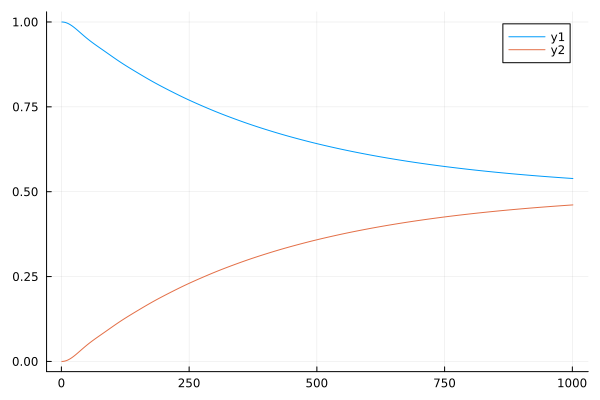

In [4]:
P = set_P()
mu = 0.0
beta = 20.0
gamma = 0.01
N = 50

P.spec_fun = "ellipse"
P.T = 100
P.N_L = N
P.N_R = N
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

T = P.T

qS = 2*N + 2 

J_L = spectral_function(P, "L")
J_R = spectral_function(P, "R")

H = H_tot(J_L, J_R, P)
C0_e = prepare_corrs(P)
C0_e[qS,qS] = 0.0
C0_f = prepare_corrs(P)
C0_f[qS,qS] = 1.0
Cs_e = evolve_corrs(C0_e, H, P, T)
Cs_f = evolve_corrs(C0_f, H, P, T)

rho1 = [real(C[qS,qS]) for C in Cs_f]
rho2 = [real(C[qS,qS]) for C in Cs_e]

p = plot(rho1)
plot!(p, rho2)

display(p)